<a href="https://colab.research.google.com/github/leesysy/basic-team/blob/main/linear_regression_numerical_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch=0: Cost=13.7179, w=0.0248, b=0.0073
Epoch=10: Cost=8.5818, w=0.2430, b=0.0717
Epoch=20: Cost=5.3996, w=0.4144, b=0.1232
Epoch=30: Cost=3.4278, w=0.5492, b=0.1644
Epoch=40: Cost=2.2058, w=0.6550, b=0.1977
Epoch=50: Cost=1.4483, w=0.7381, b=0.2247
Epoch=60: Cost=0.9785, w=0.8033, b=0.2466
Epoch=70: Cost=0.6870, w=0.8543, b=0.2647
Epoch=80: Cost=0.5058, w=0.8943, b=0.2797
Epoch=90: Cost=0.3931, w=0.9256, b=0.2922
Epoch=100: Cost=0.3227, w=0.9500, b=0.3029
Epoch=110: Cost=0.2786, w=0.9690, b=0.3120
Epoch=120: Cost=0.2507, w=0.9837, b=0.3199
Epoch=130: Cost=0.2330, w=0.9951, b=0.3269
Epoch=140: Cost=0.2214, w=1.0039, b=0.3331
Epoch=150: Cost=0.2138, w=1.0106, b=0.3388
Epoch=160: Cost=0.2086, w=1.0157, b=0.3440
Epoch=170: Cost=0.2048, w=1.0194, b=0.3488
Epoch=180: Cost=0.2020, w=1.0222, b=0.3534
Epoch=190: Cost=0.1998, w=1.0242, b=0.3577

최종 결과:
w = 1.0254
b = 0.3614


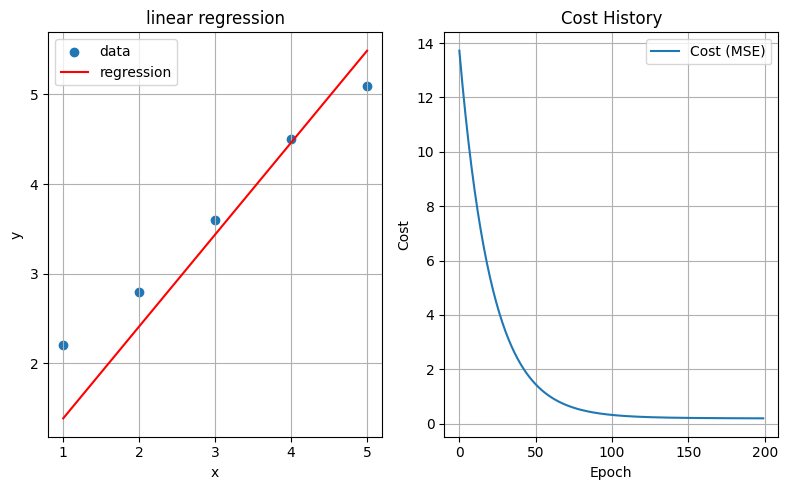

In [1]:

import numpy as np
import matplotlib.pyplot as plt


# 1. 비용 함수 정의 (Mean Squared Error)
def compute_cost(x, y, w, b):
    # x: 입력변수
    # y: 출력변수
    # w: 웨이트
    # b: 바이어스
    y_pred = w * x + b
    cost   = np.mean((y_pred -y)**2)
    return cost

# 2. 수치 그래디언트
def numerical_gradient(f,x,y,w,b):
    # f: cost function
    # x: 입력변수
    # y: 출력변수
    # w: 웨이트
    # b: 바이어스
    h = 1e-4 #0.0001
    grad_w = (f(x,y,w+h,b)   - f(x,y,w,b))/h
    grad_b = (f(x,y,w,  b+h) - f(x,y,w,b))/h
    return grad_w, grad_b

# 1. 데이터 준비
x = np.array([1,   2,   3,   4,   5])
y = np.array([2.2, 2.8, 3.6, 4.5, 5.1])

# 2. 초기 파라미터 설정
w = 0.0  # 기울기
b = 0.0  # 절편

# 하이퍼파라미터
learning_rate = 0.1
epochs = 200

n = len(x)  # 데이터 개수


# 4. 경사하강법 학습 루프
cost_history = []

for i in range(epochs):
    #y_pred = w * x + b
    #error = y_pred - y

    # 기울기 계산
    # dw = (2 / n) * np.sum(error * x)
    # db = (2 / n) * np.sum(error)

    # 수치미분 계산
    dw, db = numerical_gradient(compute_cost,x,y,w,b)

    # 파라미터 업데이트
    w -=  learning_rate * dw
    b -=  learning_rate * db

    # 비용 기록
    cost = compute_cost(x, y, w, b)
    cost_history.append(cost)

    # 중간 출력
    if i % 10 == 0:
        print(f"Epoch={i}: Cost={cost:.4f}, w={w:.4f}, b={b:.4f}")

# 5. 최종 결과 출력
print("\n최종 결과:")
print(f"w = {w:.4f}")
print(f"b = {b:.4f}")

# 6. 회귀선 시각화
y_fit = w * x + b
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.scatter(x, y, label='data')
plt.plot(x, y_fit, color='red', label='regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('linear regression')
plt.legend()
plt.grid(True)

# 7. 비용 함수 감소 시각화
plt.subplot(1, 2, 2)
plt.plot(cost_history, label='Cost (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Cost History')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()